# AICE 모의고사 4회 - 기후 변화 예측

## 문제 시나리오

과거 기상 정보 및 환경 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 특정 지역의 연간 평균 기온을 변화를 예측하고 결과를 분석하세요.


## 4-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

- 필요한 패키지를 임포트 pandas 라이브러리를 pd라는 별칭으로 임포트하고, 두 개의 데이터를 분석에 활용하는 코드를 작성하세요.
- climate_data.json 파일을 읽어 데이터프레임 변수 df_climate에 할당하세요.
- pollution_data.csv 파일을 읽어 데이터프레임 변수 df_pollution에 할당하세요.


In [118]:
# 라이브러리 임포트
import pandas as pd

In [119]:
# 데이터 불러오기
df_climate = pd.read_json('C:/juehyeon/aice_test/기출문제/4.기후변화예측/climate_data.json')

In [120]:
df_pollution = pd.read_csv('C:/juehyeon/aice_test/기출문제/4.기후변화예측/pollution_data.csv')

In [121]:
# 데이터 확인하기
df_climate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   LocationID             150 non-null    int64  
 1   Year                   150 non-null    int64  
 2   AvgTemperature_C       150 non-null    float64
 3   CO2_Concentration_ppm  150 non-null    int64  
 4   SeaLevel_mm            144 non-null    float64
 5   ForestArea_percent     150 non-null    float64
 6   UrbanArea_percent      150 non-null    float64
 7   MajorEvent             150 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 9.5+ KB


## 4-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

- 두 개의 데이터프레임(df_climate, df_pollution)을 LocationID와 Year 컬럼을 기준으로 병합하고, 병합된 데이터프레임의 상위 5개 행과 컬럼별 요약 정보를 출력하여 초기 데이터를 탐색하는 코드를 작성하세요.
- pandas의 merge 함수를 사용하여 df_climate와 df_pollution을 LocationID와 Year를 키(key)로 병합하고 df 변수에 저장하세요.
- 병합 방식은 inner로 지정하세요.
- df 데이터프레임의 상위 5개 행을 출력하세요.
- df 데이터프레임의 컬럼별 정보(dtype, Non-null Count)를 확인하세요.


In [122]:
# 데이터 병합하기
df = pd.merge(df_climate, df_pollution, on = ['LocationID', 'Year'], how = 'inner')

In [123]:
# 데이터프레임 5개행 출력
df.head()

,LocationID,Year,AvgTemperature_C,CO2_Concentration_ppm,SeaLevel_mm,ForestArea_percent,UrbanArea_percent,MajorEvent,PM25_ug_m3,Ozone_ppb,IndustrialEmissions_tons
0,16,2012,15.43,592,2.7,58.4,32.3,Flood,63.7,65.4,1488
1,8,2021,27.74,450,3.4,53.2,37.5,Flood,52.8,69.1,8099
2,17,2016,29.53,403,1.6,30.5,33.5,Storm,38.3,21.2,45298
3,5,2019,29.67,446,1.8,37.9,36.3,Storm,74.5,63.2,33376
4,5,2019,29.67,446,1.8,37.9,36.3,Storm,20.6,94.4,13329


In [124]:
# 데이터 컬럼별 정보 확인
df.info() # 결측치 확인: SeaLevel_mm 1개

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   LocationID                41 non-null     int64  
 1   Year                      41 non-null     int64  
 2   AvgTemperature_C          41 non-null     float64
 3   CO2_Concentration_ppm     41 non-null     int64  
 4   SeaLevel_mm               40 non-null     float64
 5   ForestArea_percent        41 non-null     float64
 6   UrbanArea_percent         41 non-null     float64
 7   MajorEvent                41 non-null     object 
 8   PM25_ug_m3                41 non-null     float64
 9   Ozone_ppb                 41 non-null     float64
 10  IndustrialEmissions_tons  41 non-null     int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 3.7+ KB


## 4-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

- MajorEvent 컬럼의 분포를 시각화하고, 데이터 경제를 위해 'Unknown' 값을 가진 행을 제거하는 코드를 작성하세요.
- seaborn 라이브러리의 countplot을 사용하여 MajorEvent 컬럼의 분포를 시각화하세요.
- MajorEvent 컬럼 값이 'Unknown'인 행을 데이터프레임에서 삭제하세요.

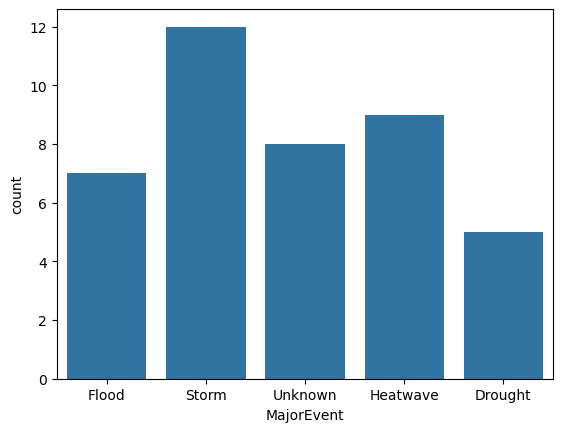

In [125]:
# 라이브러리 임포트
import seaborn as sns
import matplotlib.pyplot as plt
# 데이터 시각화
sns.countplot(data = df, x = 'MajorEvent')
plt.show()

In [126]:
# 행 삭제
df = df[df.MajorEvent != 'Unknown']

In [127]:
# 삭제 확인
df.MajorEvent.unique()

array(['Flood', 'Storm', 'Heatwave', 'Drought'], dtype=object)

## 4-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

- CO2_Concentration_ppm과 AvgTemperature_C 간의 관계를 jointplot으로 시각화하고, CO2_Concentration_ppm가 500 이상인 이상치를 찾아 행의 개수를 확인하는 코드를 작성하세요.
- seaborn 라이브러리의 jointplot을 사용하여 x축에 CO2_Concentration_ppm, y축에 AvgTemperature_C를 표시하세요.
- CO2_Concentration_ppm가 500 이상인 행의 개수를 세어 출력하세요.

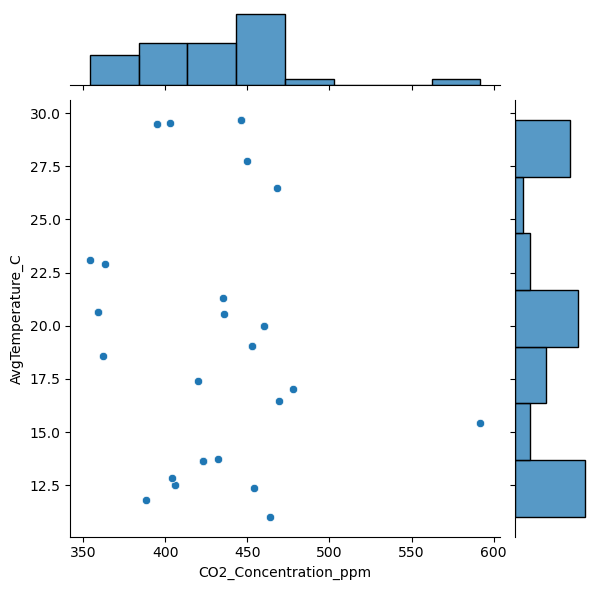

In [128]:
# 데이터 시각화
sns.jointplot(data = df, x = 'CO2_Concentration_ppm', y = 'AvgTemperature_C')
plt.show()

In [129]:
# CO2가 500개 이상인 행 개수 
CO2_rows = (df.CO2_Concentration_ppm >= 500).sum()
print(CO2_rows)

1



## 4-5 | 이상치 및 불필요 컬럼 처리

### 【 문제 】

- CO2_Concentration_ppm가 500 이상인 이상치 행을 삭제하고, 모델링에 불필요한 LocationID와 Year 컬럼을 삭제하는 코드를 작성하세요.
- CO2_Concentration_ppm가 500 미만인 행만 남기고 데이터프레임을 업데이트하세요.
- LocationID와 Year 컬럼을 데이터프레임에서 삭제하세요.
- 변경된 데이터프레임을 df_cleaned에 저장하세요.

In [130]:
# 이상치 삭제
df = df[df.CO2_Concentration_ppm < 500]

In [131]:
# 이상치 삭제 확인
new_rows = (df.CO2_Concentration_ppm >= 500).sum()
new_rows

np.int64(0)

In [132]:
# 이상치 삭제 확인 2
(df.CO2_Concentration_ppm).max()

478

In [133]:
# 컬럼 삭제
del_cols = ['LocationID', 'Year']
df = df.drop(columns = del_cols)

In [134]:
# 컬럼 삭제 확인
df.columns

Index(['AvgTemperature_C', 'CO2_Concentration_ppm', 'SeaLevel_mm',
       'ForestArea_percent', 'UrbanArea_percent', 'MajorEvent', 'PM25_ug_m3',
       'Ozone_ppb', 'IndustrialEmissions_tons'],
      dtype='object')

In [135]:
# 변수 재할당 
df_cleaned = df.copy()

## 4-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

- 데이터프레임에 결측치가 있는지 확인하고, 결측치가 있는 행을 삭제한 뒤, SeaLevel_mm 컬럼을 정수형(int)으로 변환하세요.
- df_cleaned의 결측치를 확인하는 코드를 작성하세요.


In [136]:
# 결측치 확인
df_cleaned.isna().sum()

AvgTemperature_C            0
CO2_Concentration_ppm       0
SeaLevel_mm                 0
ForestArea_percent          0
UrbanArea_percent           0
MajorEvent                  0
PM25_ug_m3                  0
Ozone_ppb                   0
IndustrialEmissions_tons    0
dtype: int64

In [137]:
# 정수형 변환
df_cleaned['SeaLevel_mm'] = df_cleaned['SeaLevel_mm'].astype(int)

In [138]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 1 to 40
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AvgTemperature_C          32 non-null     float64
 1   CO2_Concentration_ppm     32 non-null     int64  
 2   SeaLevel_mm               32 non-null     int64  
 3   ForestArea_percent        32 non-null     float64
 4   UrbanArea_percent         32 non-null     float64
 5   MajorEvent                32 non-null     object 
 6   PM25_ug_m3                32 non-null     float64
 7   Ozone_ppb                 32 non-null     float64
 8   IndustrialEmissions_tons  32 non-null     int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 2.5+ KB


## 4-7 | 불필요 컬럼 처리 및 범주형 변수 원-핫 인코딩

### 【 문제 】

- UrbanArea_percent 컬럼을 삭제하고, object 타입의 범주형 컬럼(MajorEvent)을 원-핫 인코딩하세요.
- df_processed에서 UrbanArea_percent 컬럼을 삭제하세요.
- pandas의 get_dummies 함수를 활용하여 object 타입의 컬럼에 대해 원-핫 인코딩을 수행하세요.
- 변경된 결과를 df_encoded 변수에 저장하세요.


In [139]:
# 컬럼 삭제  (df_processed 할당 조건 없어서 임의로 없이 진행)
df_cleaned = df_cleaned.drop(columns = 'UrbanArea_percent')

In [140]:
# 삭제 확인
df_cleaned.columns

Index(['AvgTemperature_C', 'CO2_Concentration_ppm', 'SeaLevel_mm',
       'ForestArea_percent', 'MajorEvent', 'PM25_ug_m3', 'Ozone_ppb',
       'IndustrialEmissions_tons'],
      dtype='object')

In [141]:
# 원-핫 인코딩
df_cleaned = pd.get_dummies(data = df_cleaned, columns = ['MajorEvent'])

In [142]:
df_encoded = df_cleaned.copy()

## 4-8 | 데이터 분리 및 스케일링

### 【 문제 】

- 최종 기온(AvgTemperature_C)을 예측하기 위해 데이터를 훈련 및 검증 데이터로 분리하고, 스케일링을 수행하세요.
- AvgTemperature_C 컬럼을 y 변수에, 나머지 컬럼을 X 변수에 할당하세요.
- scikit-learn의 train_test_split 함수를 사용하여 X와 y를 훈련 데이터(80%)와 검증 데이터(20%)으로 분리하세요. random_state는 42로 설정하세요.
- sklearn.preprocessing의 StandardScaler를 사용하여 훈련 데이터와의 Feature(X_train)를 스케일링하고 X_train_scaled에 할당하세요.
- StandardScaler의 transform 함수를 사용하여 검증 데이터와의 Feature(X_valid)를 스케일링하고 X_valid_scaled에 할당하세요.

In [143]:
# 라이브러리 임포트
from sklearn.model_selection import train_test_split

In [144]:
# 데이터 분리
X = df_encoded.drop(columns = 'AvgTemperature_C')
y = df_encoded['AvgTemperature_C']

In [145]:
# 훈련 / 검증 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [146]:
# 라이브러리 임포트
from sklearn.preprocessing import StandardScaler

In [147]:
# 모델 객체 생성
scaler = StandardScaler()

In [148]:
# 데이터 스케일링
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

## 4-9 | 머신러닝 모델 학습(Random Forest Regressor)

### 【 문제 】

- scikit-learn의 RandomForestRegressor 모델을 생성하고 학습하세요.
- 모델의 n_estimators는 100, max_depth는 5, random_state는 42로 설정하세요.
- 모델을 rfr_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.

In [149]:
# 라이브러리 임포트
from sklearn.ensemble import RandomForestRegressor

In [150]:
# 모델 객체 생성
rfr_model = RandomForestRegressor(n_estimators = 100, max_depth = 5, random_state = 42)

In [151]:
# 데이터 학습
rfr_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



## 4-10 | 머신러닝 모델 학습(Support Vector Regressor)

### 【 문제 】

- scikit-learn의 SVR(Support Vector Regressor) 모델을 생성하고 학습하세요.
- 모델의 커널(kernel)은 rbf, C는 10, gamma는 auto로 설정하세요.
- 모델을 svr_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.

In [152]:
# 라이브러리 임포트
from sklearn.svm import SVR

In [153]:
# 모델 객체 생성
svr_model = SVR(kernel = 'rbf', C = 10, gamma = 'auto')

In [154]:
# 모델 학습
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## 4-11 | 머신러닝 모델 성능 평가(MAE 비교)

### 【 문제 】

- 두 머신러닝 모델(rfr_model, svr_model)의 성능을 검증 데이터를 사용하여 MAE(Mean Absolute Error)로 평가하고, 더 우수한 성능을 보인 모델의 이름을 answer11 변수에 저장하세요.
- rfr_model과 svr_model을 사용하여 검증 데이터(X_valid_scaled)에 대한 예측 값을 각각 rfr_pred, svr_pred에 저장하세요.
- scikit-learn의 mean_absolute_error 함수를 사용하여 두 모델의 MAE를 계산하고 각각 rfr_mae, svr_mae에 저장하세요.
- 두 MAE 값을 비교하여 더 작은 값을 가진 모델의 이름을 answer11 변수에 저장하세요(예: 'RandomForestRegressor', 'SVR')에 저장하세요.


In [155]:
# 라이브러리 임포트
from sklearn.metrics import mean_absolute_error

In [156]:
# 모델 예측
rfr_pred = rfr_model.predict(X_valid_scaled)
svr_pred = svr_model.predict(X_valid_scaled)

In [157]:
# 모델 평가
rfr_mae = mean_absolute_error(y_valid, rfr_pred)
svr_mae = mean_absolute_error(y_valid, svr_pred)

In [158]:
# 결과 확인
print(f' Random Forest Regressor : {rfr_mae}, Support Vector Regressor : {svr_mae}')

 Random Forest Regressor : 5.760513886787813, Support Vector Regressor : 4.727241541812589


In [159]:
answer11 = 'SVR'


## 4-12 | 딥러닝 모델 개발 및 학습

### 【 문제 】

- tensorflow.keras를 사용하여 AvgTemperature_C를 예측하는 딥러닝 모델을 만들고 학습하세요.
- 히든 레이어(Hidden Layer)를 2개 이상으로 구성하세요.
- Dropout 레이어를 1개 추가하고 비율을 0.2로 설정하세요.
- 손실 함수(loss function)는 mean_squared_error를 사용하세요.
- epochs는 30, batch_size는 16으로 설정하세요.
- 학습 과정에서 검증 데이터셋(X_valid_scaled, y_valid)을 사용하여 성능을 평가하고, 학습 정보를 history 변수에 저장하세요.

In [166]:
# 라이브러리 임포트
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.models import Sequential
from sklearn.metrics import mean_squared_error

In [167]:
# 모델 생성
dl_model = Sequential([
    Input(shape = (X_train_scaled.shape[1], )),
    Dense(64, activation = 'relu'),
    Dense(32, activation = 'relu'),
    Dropout(0.2),
    Dense(1)
])

In [168]:
# 모델 컴파일
dl_model.compile(
    loss = 'mean_squared_error',
    optimizer = 'adam'
)

In [169]:
# 모델 학습 
history = dl_model.fit(X_train_scaled, y_train, 
                       epochs = 30, 
                       batch_size = 16,
                       validation_data = (X_valid_scaled, y_valid)
                      )

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step - loss: 489.0186 - val_loss: 295.6926
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 482.6201 - val_loss: 291.1735
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 474.6303 - val_loss: 286.7090
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 467.7702 - val_loss: 282.3073
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 466.6407 - val_loss: 277.9565
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 460.5063 - val_loss: 273.6043
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 456.9523 - val_loss: 269.2580
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 447.3037 - val_loss: 264.9224
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 445.4684 - val_loss: 260.5443
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 439.3257 - val_loss: 256.1244
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 431.0042 - val_loss: 251.6034
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s


## 4-13 | 딥러닝 모델 학습 성능 시각화

### 【 문제 】

- matplotlib을 활용하여 딥러닝 모델의 학습 MSE와 검증 MSE를 그래프로 표시하고, 반복에 축 레이블을 추가하여 성능 변화를 시각화하세요.
- history 변수에 저장된 학습 MSE(loss)와 검증 MSE(val_loss)를 그래프로 그리세요.
- 각각의 변화를 'Training MSE'와 'Validation MSE'로 표시하세요.
- x축에 'Epochs', y축에 'MSE'라는 레이블을 지정하세요.

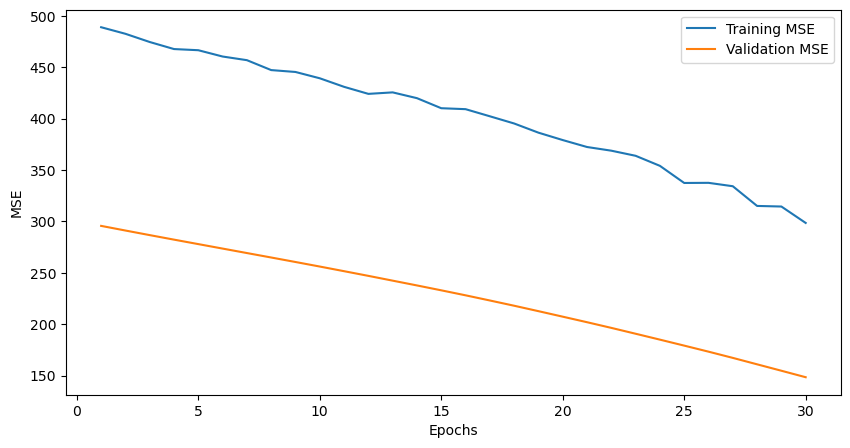

In [172]:
mse = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(mse)+1)

plt.figure(figsize=(10,5))
plt.plot(epochs, mse, label='Training MSE')
plt.plot(epochs, val_loss, label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()



## 4-14 | 최종 모델 선택 및 결론 도출

### 【 문제 】

- 모델의 과적합(overfitting)을 방지하고 최적의 성능을 가진 모델을 자동으로 저장하기 위해 EarlyStopping과 ModelCheckpoint 콜백(callbacks)을 설정하여 모델을 학습하세요.

**EarlyStopping**
- monitor를 val_loss로 설정하여 검증 손실을 모니터링하세요.
- patience는 5로 설정하여 검증 손실이 5 에포크 동안 개선되지 않으면 학습을 중단하세요.
- restore_best_weights를 True로 설정하여 학습이 중단되었을 때 가장 좋은 성능을 보인 시점의 가중치를 복원하세요.

**ModelCheckpoint**
- filepath를 'best_model.h5'로 설정하여 최적의 모델을 해당 파일명으로 저장하세요.
- monitor는 val_loss로 설정하세요.
- save_best_only를 True로 설정하여 가장 좋은 성능을 보인 모델만 저장하세요.

In [175]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [179]:
# Early Stopping
es = EarlyStopping(
    monitor = 'val_loss',
    patience = 5, 
    restore_best_weights = True
)

# Model Checkpoint
mc = ModelCheckpoint(
    'best_model.h5',
    monitor = 'val_loss',
    save_best_only = True
)